# Cognifyz Data Analysis Internship - Zomato Dataset Analysis
## Level 1 and Level 2 Tasks

This notebook performs comprehensive analysis of the Zomato restaurant dataset, including:
- **Level 1**: Cuisine analysis, city statistics, price range distribution, and online delivery insights
- **Level 2**: Rating distribution, cuisine combinations, geographic mapping, and chain analysis

## Section 1: Setup - Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium import plugins
import warnings
warnings.filterwarnings('ignore')

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create output folders for charts
import os
os.makedirs('charts', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# Define file paths
dataset_path = 'zomato.csv'
charts_folder = 'charts'
outputs_folder = 'outputs'

print("✓ Imports and configuration completed successfully!")

✓ Imports and configuration completed successfully!


## Section 2: Load Dataset and Initial Inspection

In [2]:
# Load dataset with latin-1 encoding
df = pd.read_csv(dataset_path, encoding='latin-1')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape} (rows, columns)")
print("\n" + "="*80)
print("DATASET HEAD:")
print("="*80)
print(df.head())

print("\n" + "="*80)
print("DATASET INFO:")
print("="*80)
print(df.info())

print("\n" + "="*80)
print("MISSING VALUES:")
print("="*80)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
print(missing_df[missing_df['Missing_Count'] > 0])

print("\n" + "="*80)
print("COLUMN NAMES:")
print("="*80)
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (9551, 21) (rows, columns)

DATASET HEAD:
   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Villa

## Section 3: Data Cleaning and Type Conversions

In [3]:
# Create a copy for cleaning
df_clean = df.copy()

# Handle missing values
print("Handling missing values...")
df_clean['Cuisines'] = df_clean['Cuisines'].fillna('Unknown')
df_clean['Aggregate rating'] = df_clean['Aggregate rating'].fillna(0)

# Convert data types
print("Converting data types...")
df_clean['Price range'] = pd.to_numeric(df_clean['Price range'], errors='coerce')
df_clean['Aggregate rating'] = pd.to_numeric(df_clean['Aggregate rating'], errors='coerce')
df_clean['Votes'] = pd.to_numeric(df_clean['Votes'], errors='coerce')
df_clean['Latitude'] = pd.to_numeric(df_clean['Latitude'], errors='coerce')
df_clean['Longitude'] = pd.to_numeric(df_clean['Longitude'], errors='coerce')

# Normalize boolean columns
print("Normalizing boolean columns...")
df_clean['Has Online delivery'] = df_clean['Has Online delivery'].map({'Yes':1,'No':0})
df_clean['Has Table booking'] = df_clean['Has Table booking'].map({'Yes':1,'No':0})

# Strip whitespace from text fields
df_clean['City'] = df_clean['City'].str.strip()
df_clean['Restaurant Name'] = df_clean['Restaurant Name'].str.strip()
df_clean['Cuisines'] = df_clean['Cuisines'].str.strip()

# Create helper columns for cuisine analysis
print("Creating helper columns...")
# Primary cuisine (first cuisine listed)
df_clean['Primary_Cuisine'] = df_clean['Cuisines'].str.split(',').str[0].str.strip()

# Cuisine list as array
df_clean['Cuisine_List'] = df_clean['Cuisines'].str.split(',')

# Rating range
df_clean['Rating_Range'] = pd.cut(df_clean['Aggregate rating'], 
                                   bins=[0, 2, 3, 4, 5], 
                                   labels=['0-2', '2-3', '3-4', '4-5'])

print("✓ Data cleaning completed!")
print(f"\nCleaned dataset shape: {df_clean.shape}")
print(f"Data types:\n{df_clean.dtypes}")

Handling missing values...
Converting data types...
Normalizing boolean columns...
Creating helper columns...
✓ Data cleaning completed!

Cleaned dataset shape: (9551, 24)
Data types:
Restaurant ID              int64
Restaurant Name              str
Country Code               int64
City                         str
Address                      str
Locality                     str
Locality Verbose             str
Longitude                float64
Latitude                 float64
Cuisines                     str
Average Cost for two       int64
Currency                     str
Has Table booking          int64
Has Online delivery        int64
Is delivering now            str
Switch to order menu         str
Price range                int64
Aggregate rating         float64
Rating color                 str
Rating text                  str
Votes                      int64
Primary_Cuisine           object
Cuisine_List              object
Rating_Range            category
dtype: object


# LEVEL 1 TASKS

## Level 1 - Task 1: Top 3 Cuisines and Their Percentage of Total Restaurants

In [4]:
print("="*80)
print("LEVEL 1 - TASK 1: TOP 3 CUISINES ANALYSIS")
print("="*80)

# Count primary cuisines
cuisine_counts = df_clean['Primary_Cuisine'].value_counts()
total_restaurants = len(df_clean)

# Get top 3
top_3_cuisines = cuisine_counts.head(3)

# Calculate percentages
top_3_percentages = (top_3_cuisines / total_restaurants) * 100

# Create summary dataframe
cuisine_summary = pd.DataFrame({
    'Cuisine': top_3_cuisines.index,
    'Count': top_3_cuisines.values,
    'Percentage': top_3_percentages.values
})

print("\nTOP 3 CUISINES:")
print(cuisine_summary.to_string(index=False))

print(f"\n✓ Finding: The top 3 cuisines account for {top_3_percentages.sum():.2f}% of all restaurants.")

# Save to CSV
cuisine_summary.to_csv(f'{outputs_folder}/level1_task1_top_cuisines.csv', index=False)
print(f"✓ Summary saved to: {outputs_folder}/level1_task1_top_cuisines.csv")

LEVEL 1 - TASK 1: TOP 3 CUISINES ANALYSIS

TOP 3 CUISINES:
     Cuisine  Count  Percentage
North Indian   2992   31.326563
     Chinese    855    8.951942
   Fast Food    672    7.035912

✓ Finding: The top 3 cuisines account for 47.31% of all restaurants.
✓ Summary saved to: outputs/level1_task1_top_cuisines.csv


## Level 1 - Task 2: City Analysis - Restaurant Count, Average Rating, and Highest Rated City

In [5]:
print("\n" + "="*80)
print("LEVEL 1 - TASK 2: CITY ANALYSIS")
print("="*80)

# Group by city
city_stats = df_clean.groupby('City').agg({
    'Restaurant ID': 'count',
    'Aggregate rating': 'mean',
    'Votes': 'mean'
}).rename(columns={
    'Restaurant ID': 'Restaurant_Count',
    'Aggregate rating': 'Avg_Rating',
    'Votes': 'Avg_Votes'
}).sort_values('Restaurant_Count', ascending=False)

# City with most restaurants
city_most_restaurants = city_stats['Restaurant_Count'].idxmax()
most_restaurant_count = city_stats.loc[city_most_restaurants, 'Restaurant_Count']

print(f"\n📍 CITY WITH MOST RESTAURANTS:")
print(f"   City: {city_most_restaurants}")
print(f"   Number of Restaurants: {int(most_restaurant_count)}")

# Highest rated city (considering minimum of 5 restaurants to avoid bias)
min_restaurants = 5
city_stats_filtered = city_stats[city_stats['Restaurant_Count'] >= min_restaurants]
highest_rated_city = city_stats_filtered['Avg_Rating'].idxmax()
highest_rating = city_stats_filtered.loc[highest_rated_city, 'Avg_Rating']

print(f"\n⭐ HIGHEST RATED CITY (min {min_restaurants} restaurants):")
print(f"   City: {highest_rated_city}")
print(f"   Average Rating: {highest_rating:.2f}")

print(f"\n📊 TOP 5 CITIES BY RESTAURANT COUNT:")
print(city_stats.head(5).to_string())

# Save to CSV
city_stats.to_csv(f'{outputs_folder}/level1_task2_city_stats.csv')
print(f"\n✓ Summary saved to: {outputs_folder}/level1_task2_city_stats.csv")


LEVEL 1 - TASK 2: CITY ANALYSIS

📍 CITY WITH MOST RESTAURANTS:
   City: New Delhi
   Number of Restaurants: 5473

⭐ HIGHEST RATED CITY (min 5 restaurants):
   City: London
   Average Rating: 4.54

📊 TOP 5 CITIES BY RESTAURANT COUNT:
           Restaurant_Count  Avg_Rating   Avg_Votes
City                                               
New Delhi              5473    2.438845  114.807236
Gurgaon                1118    2.651431  118.211091
Noida                  1080    2.036204   68.044444
Faridabad               251    1.866932   25.840637
Ghaziabad                25    2.852000   94.640000

✓ Summary saved to: outputs/level1_task2_city_stats.csv


## Level 1 - Task 3: Price Range Distribution and Percentage Analysis


LEVEL 1 - TASK 3: PRICE RANGE DISTRIBUTION

💰 PRICE RANGE DISTRIBUTION:
 Price_Range  Count  Percentage
           1   4444   46.529159
           2   3113   32.593446
           3   1408   14.741912
           4    586    6.135483

✓ Chart saved to: charts/level1_task3_price_range_distribution.png
✓ Summary saved to: outputs/level1_task3_price_range.csv


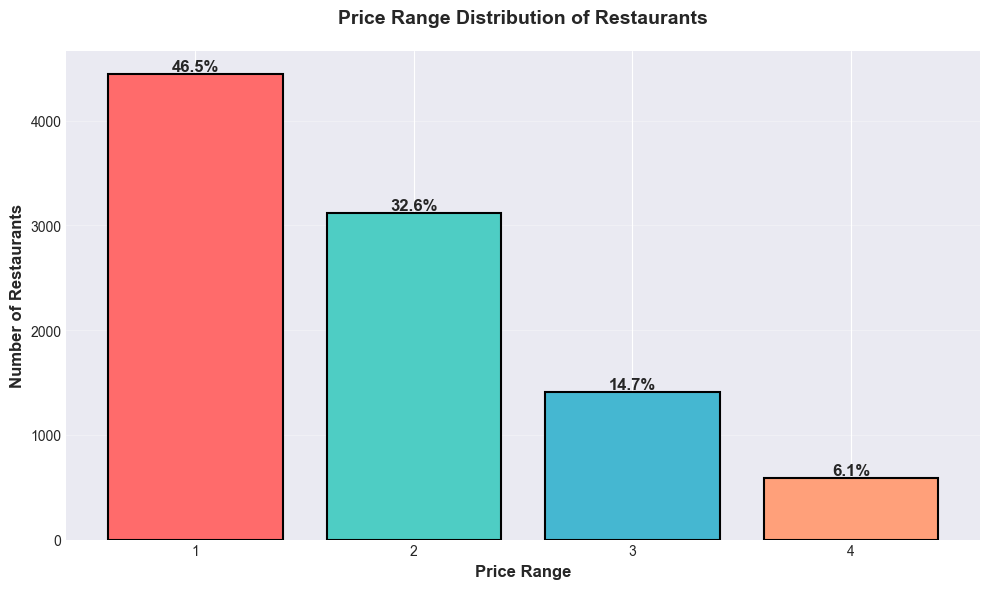

In [6]:
print("\n" + "="*80)
print("LEVEL 1 - TASK 3: PRICE RANGE DISTRIBUTION")
print("="*80)

# Remove NaN values for analysis
price_data = df_clean['Price range'].dropna()

# Count distribution
price_distribution = price_data.value_counts().sort_index()
price_percentages = (price_distribution / len(df_clean)) * 100

price_analysis = pd.DataFrame({
    'Price_Range': price_distribution.index.astype(int),
    'Count': price_distribution.values,
    'Percentage': price_percentages.values
})

print("\n💰 PRICE RANGE DISTRIBUTION:")
print(price_analysis.to_string(index=False))

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = ax.bar(price_analysis['Price_Range'].astype(str), 
              price_analysis['Count'], 
              color=colors[:len(price_analysis)],
              edgecolor='black',
              linewidth=1.5)

# Add percentage labels on bars
for i, (bar, pct) in enumerate(zip(bars, price_analysis['Percentage'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{pct:.1f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Price Range', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Restaurants', fontsize=12, fontweight='bold')
ax.set_title('Price Range Distribution of Restaurants', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{charts_folder}/level1_task3_price_range_distribution.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Chart saved to: {charts_folder}/level1_task3_price_range_distribution.png")

price_analysis.to_csv(f'{outputs_folder}/level1_task3_price_range.csv', index=False)
print(f"✓ Summary saved to: {outputs_folder}/level1_task3_price_range.csv")

plt.show()

## Level 1 - Task 4: Online Delivery Analysis and Rating Comparison


LEVEL 1 - TASK 4: ONLINE DELIVERY ANALYSIS

📦 ONLINE DELIVERY STATISTICS:
   Total Restaurants: 9551
   With Online Delivery: 2451 (25.66%)
   Without Online Delivery: 7100 (74.34%)

⭐ RATING COMPARISON:
   With Online Delivery - Avg Rating: 3.25, Avg Votes: 211
   Without Online Delivery - Avg Rating: 2.47, Avg Votes: 138

📊 SUMMARY:
        Delivery_Status  Count  Avg_Rating  Avg_Votes
   With Online Delivery   2451    3.248837 211.307222
Without Online Delivery   7100    2.465296 138.131127

✓ Chart saved to: charts/level1_task4_online_delivery_comparison.png
✓ Summary saved to: outputs/level1_task4_online_delivery.csv


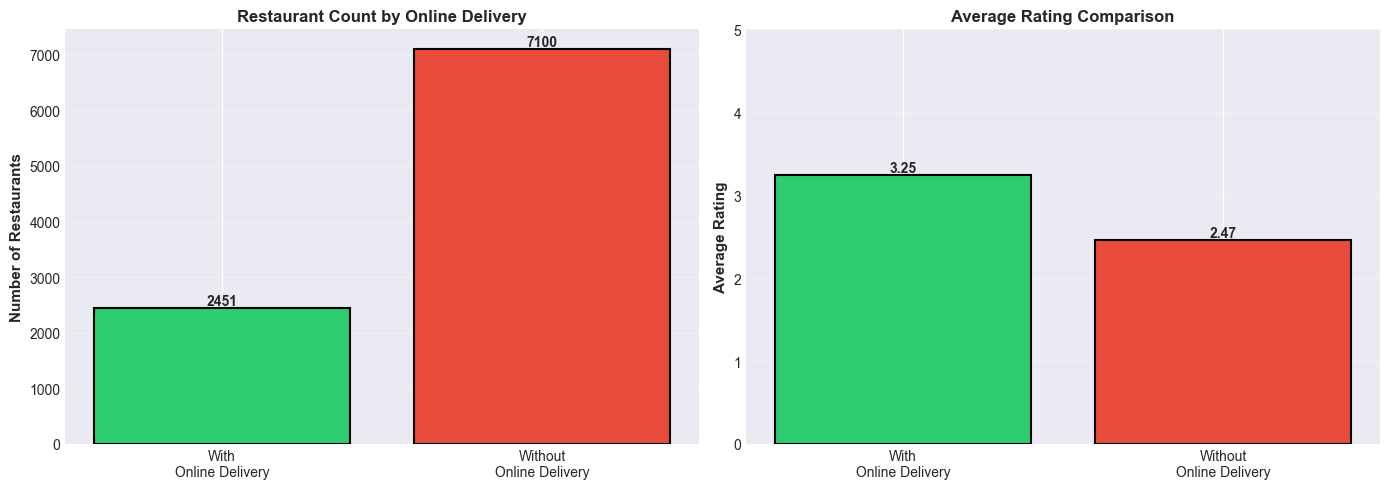

In [7]:
print("\n" + "="*80)
print("LEVEL 1 - TASK 4: ONLINE DELIVERY ANALYSIS")
print("="*80)

# Calculate online delivery percentage
total_restaurants = len(df_clean)
with_delivery = (df_clean['Has Online delivery'] == 1).sum()
without_delivery = (df_clean['Has Online delivery'] == 0).sum()
delivery_percentage = (with_delivery / total_restaurants) * 100

print(f"\n📦 ONLINE DELIVERY STATISTICS:")
print(f"   Total Restaurants: {total_restaurants}")
print(f"   With Online Delivery: {with_delivery} ({delivery_percentage:.2f}%)")
print(f"   Without Online Delivery: {without_delivery} ({100-delivery_percentage:.2f}%)")

# Rating comparison
with_delivery_data = df_clean[df_clean['Has Online delivery'] == 1]
without_delivery_data = df_clean[df_clean['Has Online delivery'] == 0]

avg_rating_with = with_delivery_data['Aggregate rating'].mean()
avg_rating_without = without_delivery_data['Aggregate rating'].mean()

avg_votes_with = with_delivery_data['Votes'].mean()
avg_votes_without = without_delivery_data['Votes'].mean()

print(f"\n⭐ RATING COMPARISON:")
print(f"   With Online Delivery - Avg Rating: {avg_rating_with:.2f}, Avg Votes: {avg_votes_with:.0f}")
print(f"   Without Online Delivery - Avg Rating: {avg_rating_without:.2f}, Avg Votes: {avg_votes_without:.0f}")

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Delivery_Status': ['With Online Delivery', 'Without Online Delivery'],
    'Count': [with_delivery, without_delivery],
    'Avg_Rating': [avg_rating_with, avg_rating_without],
    'Avg_Votes': [avg_votes_with, avg_votes_without]
})

print(f"\n📊 SUMMARY:")
print(comparison_df.to_string(index=False))

# Create comparison chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Count of restaurants
delivery_labels = ['With\nOnline Delivery', 'Without\nOnline Delivery']
delivery_counts = [with_delivery, without_delivery]
colors_delivery = ['#2ECC71', '#E74C3C']

axes[0].bar(delivery_labels, delivery_counts, color=colors_delivery, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Number of Restaurants', fontsize=11, fontweight='bold')
axes[0].set_title('Restaurant Count by Online Delivery', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add count labels
for i, (label, count) in enumerate(zip(delivery_labels, delivery_counts)):
    axes[0].text(i, count, str(count), ha='center', va='bottom', fontweight='bold')

# Chart 2: Average rating comparison
ratings = [avg_rating_with, avg_rating_without]
axes[1].bar(delivery_labels, ratings, color=colors_delivery, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Average Rating', fontsize=11, fontweight='bold')
axes[1].set_title('Average Rating Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 5)
axes[1].grid(axis='y', alpha=0.3)

# Add rating labels
for i, (label, rating) in enumerate(zip(delivery_labels, ratings)):
    axes[1].text(i, rating, f'{rating:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{charts_folder}/level1_task4_online_delivery_comparison.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Chart saved to: {charts_folder}/level1_task4_online_delivery_comparison.png")

comparison_df.to_csv(f'{outputs_folder}/level1_task4_online_delivery.csv', index=False)
print(f"✓ Summary saved to: {outputs_folder}/level1_task4_online_delivery.csv")

plt.show()

# LEVEL 2 TASKS

## Level 2 - Task 1: Aggregate Ratings Distribution, Most Common Rating Range, and Average Votes


LEVEL 2 - TASK 1: AGGREGATE RATINGS DISTRIBUTION

📊 RATING STATISTICS:
   Mean Rating: 3.44
   Median Rating: 3.40
   Mode Rating: 3.20
   Std Dev: 0.55
   Min: 1.80, Max: 4.90

🎯 MOST COMMON RATING RANGE:
   Range: 3-4
   Count: 4388 restaurants (45.94%)

💬 VOTES BY RATING RANGE:
               Avg_Votes  Count
Rating_Range                   
0-2           144.200000     10
2-3            38.991010   1891
3-4           162.152005   4388
4-5           637.413824   1114

✓ Chart saved to: charts/level2_task1_ratings_distribution.png
✓ Summary saved to: outputs/level2_task1_votes_by_range.csv


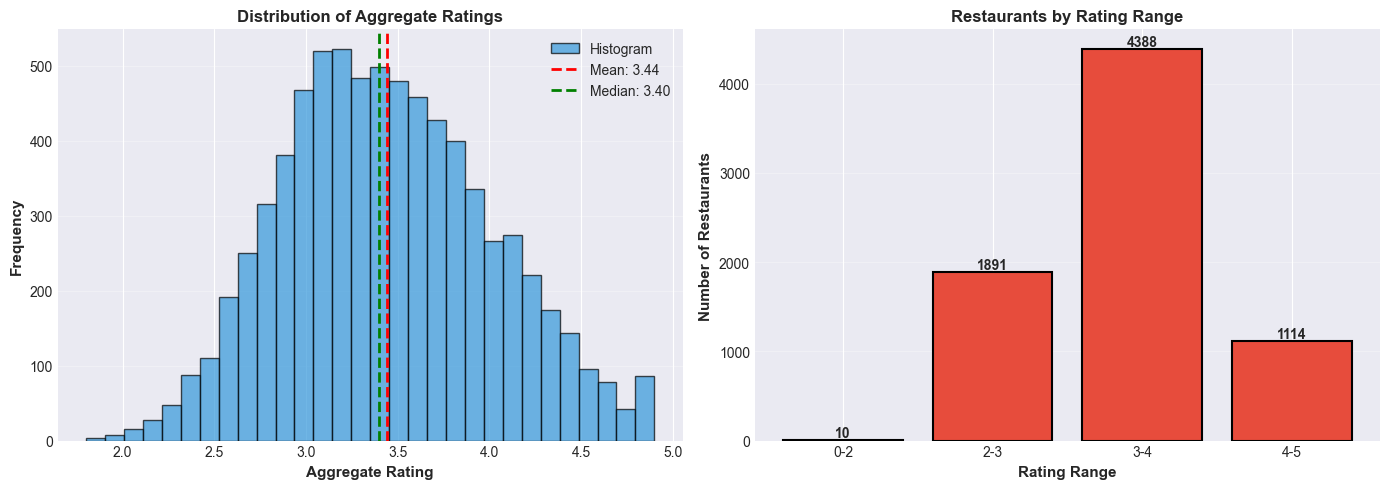

In [8]:
print("\n" + "="*80)
print("LEVEL 2 - TASK 1: AGGREGATE RATINGS DISTRIBUTION")
print("="*80)

# Remove ratings of 0 (missing values)
ratings_data = df_clean[df_clean['Aggregate rating'] > 0]['Aggregate rating']

print(f"\n📊 RATING STATISTICS:")
print(f"   Mean Rating: {ratings_data.mean():.2f}")
print(f"   Median Rating: {ratings_data.median():.2f}")
print(f"   Mode Rating: {ratings_data.mode().values[0]:.2f}")
print(f"   Std Dev: {ratings_data.std():.2f}")
print(f"   Min: {ratings_data.min():.2f}, Max: {ratings_data.max():.2f}")

# Most common rating range
rating_range_counts = df_clean['Rating_Range'].value_counts().sort_index()
most_common_range = rating_range_counts.idxmax()
most_common_count = rating_range_counts.max()

print(f"\n🎯 MOST COMMON RATING RANGE:")
print(f"   Range: {most_common_range}")
print(f"   Count: {most_common_count} restaurants ({(most_common_count/len(df_clean)*100):.2f}%)")

# Average votes per rating range
votes_by_range = df_clean.groupby('Rating_Range')['Votes'].agg(['mean', 'count'])
votes_by_range.columns = ['Avg_Votes', 'Count']

print(f"\n💬 VOTES BY RATING RANGE:")
print(votes_by_range)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
axes[0].hist(ratings_data, bins=30, color='#3498DB', edgecolor='black', alpha=0.7, label='Histogram')
axes[0].set_xlabel('Aggregate Rating', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution of Aggregate Ratings', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].axvline(ratings_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {ratings_data.mean():.2f}')
axes[0].axvline(ratings_data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {ratings_data.median():.2f}')
axes[0].legend()

# Bar plot of rating ranges
rating_range_plot = rating_range_counts.dropna()
axes[1].bar(rating_range_plot.index.astype(str), rating_range_plot.values, 
            color='#E74C3C', edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Rating Range', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Restaurants', fontsize=11, fontweight='bold')
axes[1].set_title('Restaurants by Rating Range', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add count labels
for i, (idx, val) in enumerate(zip(rating_range_plot.index, rating_range_plot.values)):
    axes[1].text(i, val, str(int(val)), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{charts_folder}/level2_task1_ratings_distribution.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Chart saved to: {charts_folder}/level2_task1_ratings_distribution.png")

votes_by_range.to_csv(f'{outputs_folder}/level2_task1_votes_by_range.csv')
print(f"✓ Summary saved to: {outputs_folder}/level2_task1_votes_by_range.csv")

plt.show()

## Level 2 - Task 2: Most Common Cuisine Combinations and Their Impact on Ratings


LEVEL 2 - TASK 2: CUISINE COMBINATIONS ANALYSIS

🍽️ TOP 10 MOST COMMON CUISINE COMBINATIONS:
Combination
North Indian                      936
Chinese, North Indian             616
Mughlai, North Indian             394
Chinese                           354
Fast Food                         354
Chinese, Mughlai, North Indian    306
Cafe                              299
Bakery                            218
Bakery, Desserts                  181
Chinese, Fast Food                159
Name: count, dtype: int64

⭐ RATING ANALYSIS FOR TOP COMBINATIONS:
                                Avg_Rating  Count  Avg_Votes
Combination                                                 
North Indian                          1.67    936      49.40
Chinese, North Indian                 2.33    616      81.38
Mughlai, North Indian                 2.77    394     175.18
Chinese                               2.04    354      61.94
Fast Food                             2.12    354      50.43
Chinese, Mughlai, No

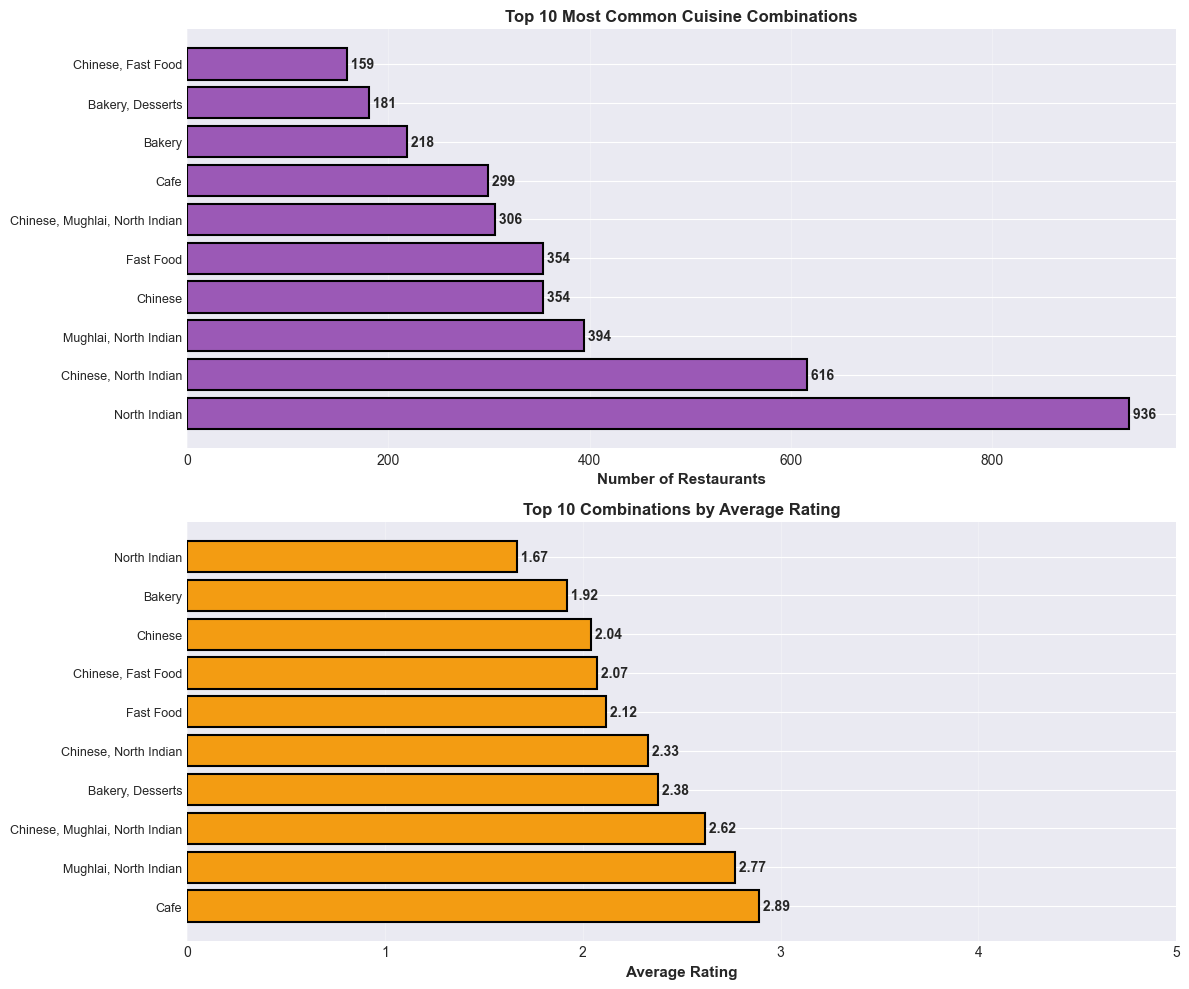

In [9]:
print("\n" + "="*80)
print("LEVEL 2 - TASK 2: CUISINE COMBINATIONS ANALYSIS")
print("="*80)

# Prepare cuisine combinations
cuisine_combos = []
for idx, cuisines in df_clean['Cuisines'].items():
    # Sort and join cuisines for consistency
    if pd.notna(cuisines) and cuisines != 'Unknown':
        cuisine_list = sorted([c.strip() for c in str(cuisines).split(',')])
        combo = ', '.join(cuisine_list)
        cuisine_combos.append({
            'Combination': combo,
            'Rating': df_clean.loc[idx, 'Aggregate rating'],
            'Votes': df_clean.loc[idx, 'Votes'],
            'Restaurant ID': df_clean.loc[idx, 'Restaurant ID']
        })

combo_df = pd.DataFrame(cuisine_combos)

# Find most common combinations
most_common_combos = combo_df['Combination'].value_counts().head(10)

print(f"\n🍽️ TOP 10 MOST COMMON CUISINE COMBINATIONS:")
print(most_common_combos)

# Analyze ratings by combination
combo_stats = combo_df.groupby('Combination').agg({
    'Rating': ['mean', 'count'],
    'Votes': 'mean'
}).round(2)
combo_stats.columns = ['Avg_Rating', 'Count', 'Avg_Votes']
combo_stats = combo_stats.sort_values('Count', ascending=False).head(10)

print(f"\n⭐ RATING ANALYSIS FOR TOP COMBINATIONS:")
print(combo_stats)

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top 10 combinations by count
top_combos_for_plot = most_common_combos.head(10)
axes[0].barh(range(len(top_combos_for_plot)), top_combos_for_plot.values, 
             color='#9B59B6', edgecolor='black', linewidth=1.5)
axes[0].set_yticks(range(len(top_combos_for_plot)))
axes[0].set_yticklabels([f"{combo[:50]}" for combo in top_combos_for_plot.index], fontsize=9)
axes[0].set_xlabel('Number of Restaurants', fontsize=11, fontweight='bold')
axes[0].set_title('Top 10 Most Common Cuisine Combinations', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Add count labels
for i, v in enumerate(top_combos_for_plot.values):
    axes[0].text(v, i, f' {int(v)}', va='center', fontweight='bold')

# Top combinations by average rating
top_by_rating = combo_stats.nlargest(10, 'Avg_Rating')
axes[1].barh(range(len(top_by_rating)), top_by_rating['Avg_Rating'].values, 
             color='#F39C12', edgecolor='black', linewidth=1.5)
axes[1].set_yticks(range(len(top_by_rating)))
axes[1].set_yticklabels([f"{combo[:50]}" for combo in top_by_rating.index], fontsize=9)
axes[1].set_xlabel('Average Rating', fontsize=11, fontweight='bold')
axes[1].set_title('Top 10 Combinations by Average Rating', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 5)
axes[1].grid(axis='x', alpha=0.3)

# Add rating labels
for i, v in enumerate(top_by_rating['Avg_Rating'].values):
    axes[1].text(v, i, f' {v:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{charts_folder}/level2_task2_cuisine_combinations.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Chart saved to: {charts_folder}/level2_task2_cuisine_combinations.png")

combo_stats.to_csv(f'{outputs_folder}/level2_task2_cuisine_combinations.csv')
print(f"✓ Summary saved to: {outputs_folder}/level2_task2_cuisine_combinations.csv")

plt.show()

## Level 2 - Task 3: Geographic Mapping of Restaurant Locations and Cluster Identification


LEVEL 2 - TASK 3: GEOGRAPHIC MAPPING & CLUSTER ANALYSIS

🗺️ MAPPING STATISTICS:
   Total Restaurants with Coordinates: 9551
   Unique Cities: 141
   Map Center: (25.8544, 64.1266)

✓ Interactive map saved to: charts/level2_task3_restaurant_map.html
   (Open this file in a browser to view the interactive map)

🏘️ TOP CITIES BY RESTAURANT CONCENTRATION:
              Restaurant_Count   Latitude  Longitude  Aggregate rating
City                                                                  
New Delhi                 5473  27.398205  73.903792          2.438845
Gurgaon                   1118  27.244718  73.762572          2.651431
Noida                     1080  26.106910  70.627131          2.036204
Faridabad                  251  25.941119  70.535371          1.866932
Ghaziabad                   25  28.637475  77.362470          2.852000
Bhubaneshwar                21  16.453017  69.477857          3.980952
Lucknow                     21  21.738139  65.553365          4.195238
Guwaha

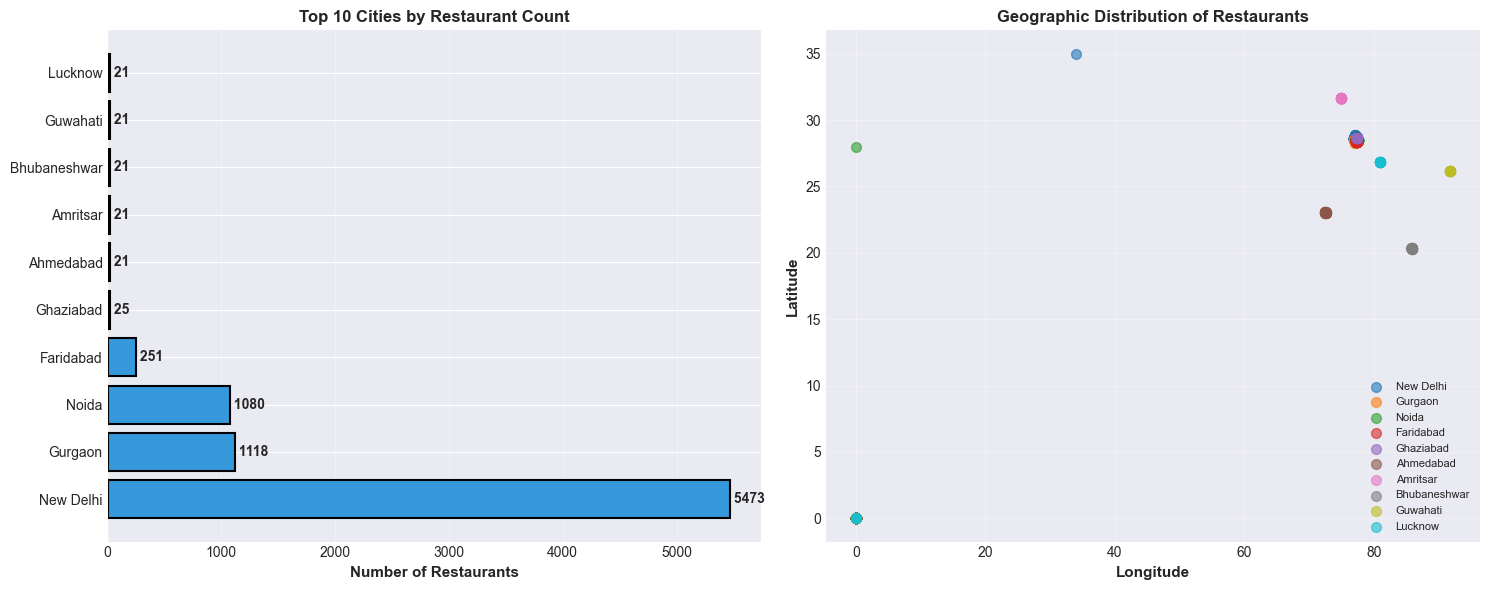

In [10]:
print("\n" + "="*80)
print("LEVEL 2 - TASK 3: GEOGRAPHIC MAPPING & CLUSTER ANALYSIS")
print("="*80)

# Prepare data for mapping - remove null coordinates
map_data = df_clean.dropna(subset=['Latitude', 'Longitude'])

print(f"\n🗺️ MAPPING STATISTICS:")
print(f"   Total Restaurants with Coordinates: {len(map_data)}")
print(f"   Unique Cities: {map_data['City'].nunique()}")

# Calculate center of map
center_lat = map_data['Latitude'].mean()
center_lng = map_data['Longitude'].mean()

print(f"   Map Center: ({center_lat:.4f}, {center_lng:.4f})")

# Create base map
zomato_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=10,
    tiles='OpenStreetMap'
)

# Add marker cluster
marker_cluster = plugins.MarkerCluster().add_to(zomato_map)

# Add individual markers with popups
for idx, row in map_data.head(500).iterrows():  # Limit to 500 for performance
    popup_text = f"""
    <b>{row['Restaurant Name']}</b><br>
    City: {row['City']}<br>
    Rating: {row['Aggregate rating']:.1f}/5<br>
    Cuisines: {row['Cuisines']}<br>
    Votes: {int(row['Votes'])}
    """
    
    # Color code by rating
    if row['Aggregate rating'] >= 4:
        color = 'green'
    elif row['Aggregate rating'] >= 3:
        color = 'orange'
    else:
        color = 'red'
    
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        popup=folium.Popup(popup_text, max_width=250),
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.7,
        weight=2
    ).add_to(zomato_map)

# Save map
map_file = f'{charts_folder}/level2_task3_restaurant_map.html'
zomato_map.save(map_file)
print(f"\n✓ Interactive map saved to: {map_file}")
print("   (Open this file in a browser to view the interactive map)")

# Analyze geographic clusters by city
city_locations = map_data.groupby('City').agg({
    'Restaurant ID': 'count',
    'Latitude': 'mean',
    'Longitude': 'mean',
    'Aggregate rating': 'mean'
}).rename(columns={'Restaurant ID': 'Restaurant_Count'}).sort_values('Restaurant_Count', ascending=False)

print(f"\n🏘️ TOP CITIES BY RESTAURANT CONCENTRATION:")
print(city_locations.head(10))

# Visualization - scatter plot of locations colored by city
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# City distribution
city_counts = map_data['City'].value_counts().head(10)
axes[0].barh(range(len(city_counts)), city_counts.values, color='#3498DB', edgecolor='black', linewidth=1.5)
axes[0].set_yticks(range(len(city_counts)))
axes[0].set_yticklabels(city_counts.index, fontsize=10)
axes[0].set_xlabel('Number of Restaurants', fontsize=11, fontweight='bold')
axes[0].set_title('Top 10 Cities by Restaurant Count', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Add count labels
for i, v in enumerate(city_counts.values):
    axes[0].text(v, i, f' {int(v)}', va='center', fontweight='bold')

# Scatter plot with city colors
cities_to_plot = city_counts.index.tolist()
colors_map = plt.cm.tab10(np.linspace(0, 1, len(cities_to_plot)))

for i, city in enumerate(cities_to_plot):
    city_data = map_data[map_data['City'] == city]
    axes[1].scatter(city_data['Longitude'], city_data['Latitude'], 
                   label=city, alpha=0.6, s=50, color=colors_map[i])

axes[1].set_xlabel('Longitude', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Latitude', fontsize=11, fontweight='bold')
axes[1].set_title('Geographic Distribution of Restaurants', fontsize=12, fontweight='bold')
axes[1].legend(loc='best', fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{charts_folder}/level2_task3_geographic_clusters.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Chart saved to: {charts_folder}/level2_task3_geographic_clusters.png")

city_locations.to_csv(f'{outputs_folder}/level2_task3_city_locations.csv')
print(f"✓ Summary saved to: {outputs_folder}/level2_task3_city_locations.csv")

plt.show()

## Level 2 - Task 4: Restaurant Chains Identification and Analysis


LEVEL 2 - TASK 4: RESTAURANT CHAINS ANALYSIS

🔗 CHAIN IDENTIFICATION:
   Total Unique Restaurants: 7446
   Number of Chains (2+ outlets): 734
   Restaurants in Chains: 2839
   Single Outlets: 6712

⭐ TOP 15 RESTAURANT CHAINS BY NUMBER OF OUTLETS:
   Cafe Coffee Day: 83 outlets, Avg Rating: 2.42, Cities: 5, Total Votes: 2428
   Domino's Pizza: 79 outlets, Avg Rating: 2.74, Cities: 7, Total Votes: 6643
   Subway: 63 outlets, Avg Rating: 2.91, Cities: 5, Total Votes: 6124
   Green Chick Chop: 51 outlets, Avg Rating: 2.67, Cities: 4, Total Votes: 964
   McDonald's: 48 outlets, Avg Rating: 3.34, Cities: 7, Total Votes: 5291
   Keventers: 34 outlets, Avg Rating: 2.87, Cities: 4, Total Votes: 1263
   Pizza Hut: 30 outlets, Avg Rating: 3.32, Cities: 12, Total Votes: 4961
   Giani: 29 outlets, Avg Rating: 2.69, Cities: 4, Total Votes: 854
   Baskin Robbins: 28 outlets, Avg Rating: 1.86, Cities: 5, Total Votes: 428
   Barbeque Nation: 26 outlets, Avg Rating: 4.35, Cities: 22, Total Votes: 28142

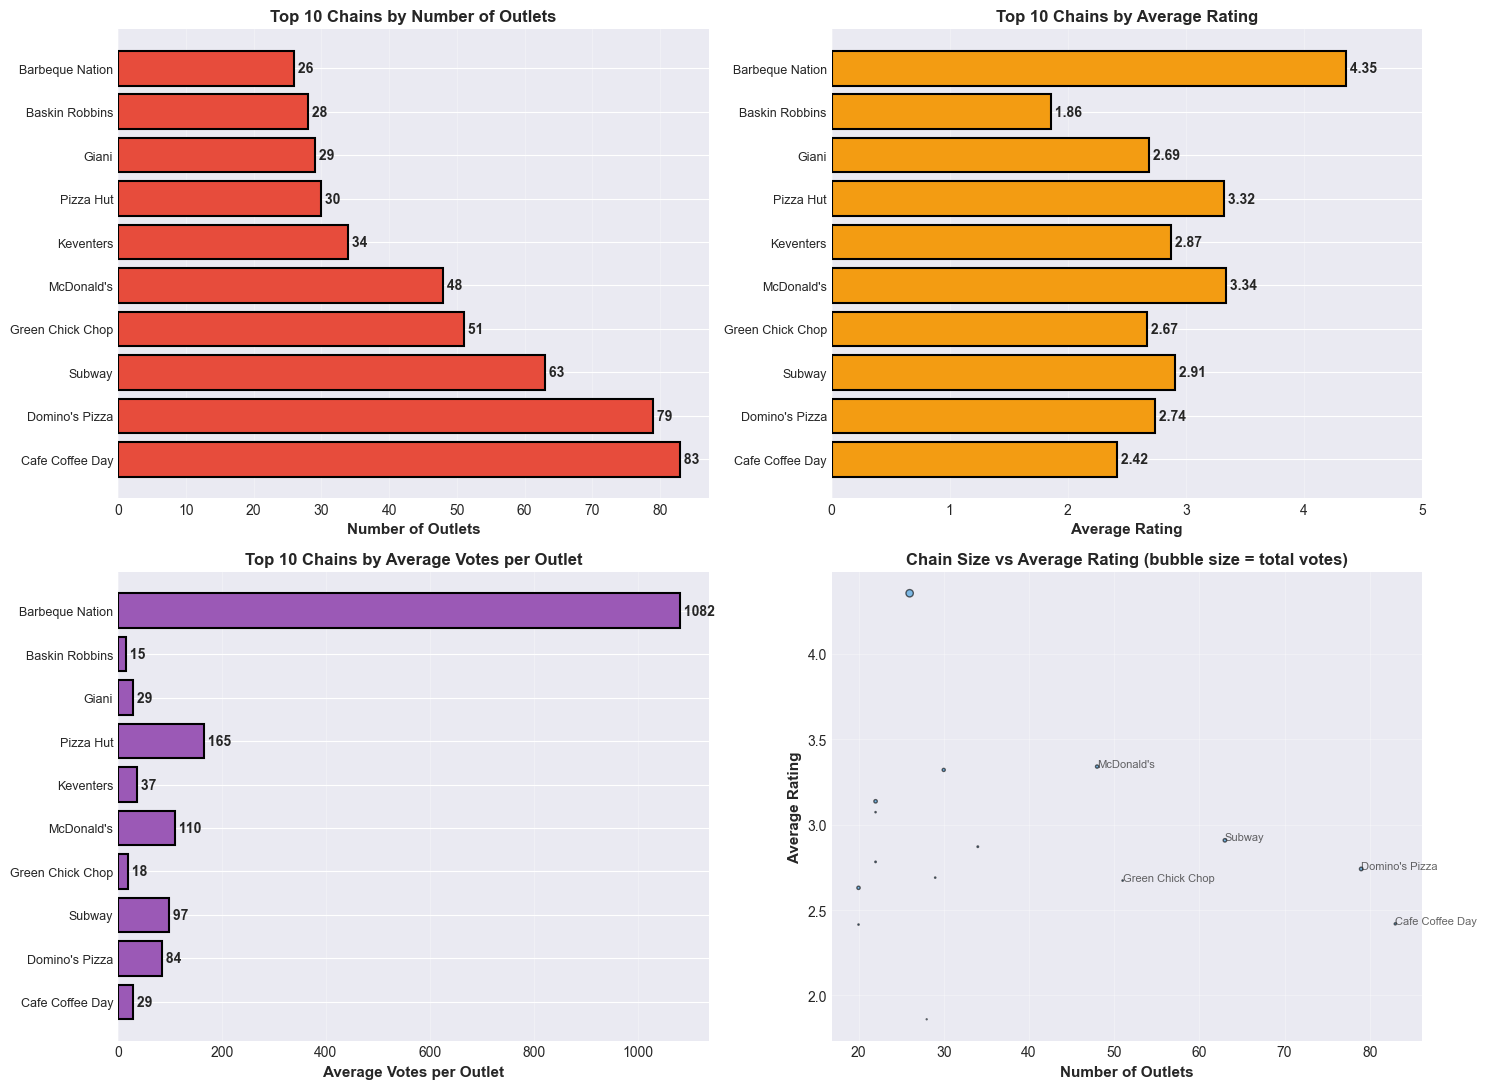

In [11]:
print("\n" + "="*80)
print("LEVEL 2 - TASK 4: RESTAURANT CHAINS ANALYSIS")
print("="*80)

# Identify chains - restaurants with same name appearing in multiple locations
restaurant_name_counts = df_clean['Restaurant Name'].value_counts()
chains = restaurant_name_counts[restaurant_name_counts > 1]

print(f"\n🔗 CHAIN IDENTIFICATION:")
print(f"   Total Unique Restaurants: {df_clean['Restaurant Name'].nunique()}")
print(f"   Number of Chains (2+ outlets): {len(chains)}")
print(f"   Restaurants in Chains: {chains.sum()}")
print(f"   Single Outlets: {len(restaurant_name_counts[restaurant_name_counts == 1])}")

# Analyze top chains
top_chains = chains.head(15)

print(f"\n⭐ TOP 15 RESTAURANT CHAINS BY NUMBER OF OUTLETS:")
for chain_name, count in top_chains.items():
    chain_data = df_clean[df_clean['Restaurant Name'] == chain_name]
    avg_rating = chain_data['Aggregate rating'].mean()
    total_votes = chain_data['Votes'].sum()
    cities = chain_data['City'].nunique()
    print(f"   {chain_name}: {count} outlets, Avg Rating: {avg_rating:.2f}, Cities: {cities}, Total Votes: {int(total_votes)}")

# Create detailed analysis dataframe
chain_analysis = []
for chain_name in top_chains.index:
    chain_data = df_clean[df_clean['Restaurant Name'] == chain_name]
    chain_analysis.append({
        'Chain_Name': chain_name,
        'Number_of_Outlets': len(chain_data),
        'Avg_Rating': chain_data['Aggregate rating'].mean(),
        'Std_Rating': chain_data['Aggregate rating'].std(),
        'Total_Votes': chain_data['Votes'].sum(),
        'Avg_Votes_per_Outlet': chain_data['Votes'].mean(),
        'Number_of_Cities': chain_data['City'].nunique(),
        'Price_Range': chain_data['Price range'].mode().values[0] if len(chain_data['Price range'].mode()) > 0 else 0
    })

chain_df = pd.DataFrame(chain_analysis).sort_values('Number_of_Outlets', ascending=False)

print(f"\n📊 DETAILED CHAIN STATISTICS:")
print(chain_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Top chains by number of outlets
chain_names = chain_df['Chain_Name'].head(10).values
outlet_counts = chain_df['Number_of_Outlets'].head(10).values

axes[0, 0].barh(range(len(chain_names)), outlet_counts, color='#E74C3C', edgecolor='black', linewidth=1.5)
axes[0, 0].set_yticks(range(len(chain_names)))
axes[0, 0].set_yticklabels(chain_names, fontsize=9)
axes[0, 0].set_xlabel('Number of Outlets', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Top 10 Chains by Number of Outlets', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

for i, v in enumerate(outlet_counts):
    axes[0, 0].text(v, i, f' {int(v)}', va='center', fontweight='bold')

# Average rating of top chains
avg_ratings = chain_df['Avg_Rating'].head(10).values
axes[0, 1].barh(range(len(chain_names)), avg_ratings, color='#F39C12', edgecolor='black', linewidth=1.5)
axes[0, 1].set_yticks(range(len(chain_names)))
axes[0, 1].set_yticklabels(chain_names, fontsize=9)
axes[0, 1].set_xlabel('Average Rating', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Top 10 Chains by Average Rating', fontsize=12, fontweight='bold')
axes[0, 1].set_xlim(0, 5)
axes[0, 1].grid(axis='x', alpha=0.3)

for i, v in enumerate(avg_ratings):
    axes[0, 1].text(v, i, f' {v:.2f}', va='center', fontweight='bold')

# Average votes comparison
avg_votes = chain_df['Avg_Votes_per_Outlet'].head(10).values
axes[1, 0].barh(range(len(chain_names)), avg_votes, color='#9B59B6', edgecolor='black', linewidth=1.5)
axes[1, 0].set_yticks(range(len(chain_names)))
axes[1, 0].set_yticklabels(chain_names, fontsize=9)
axes[1, 0].set_xlabel('Average Votes per Outlet', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Top 10 Chains by Average Votes per Outlet', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

for i, v in enumerate(avg_votes):
    axes[1, 0].text(v, i, f' {int(v)}', va='center', fontweight='bold')

# Scatter plot: Outlets vs Average Rating
axes[1, 1].scatter(chain_df['Number_of_Outlets'], chain_df['Avg_Rating'], 
                   s=chain_df['Total_Votes']/1000, alpha=0.6, color='#3498DB', edgecolor='black', linewidth=1)
axes[1, 1].set_xlabel('Number of Outlets', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Average Rating', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Chain Size vs Average Rating (bubble size = total votes)', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# Annotate top chains
for idx, row in chain_df.head(5).iterrows():
    axes[1, 1].annotate(row['Chain_Name'], 
                       (row['Number_of_Outlets'], row['Avg_Rating']),
                       fontsize=8, alpha=0.7)

plt.tight_layout()
plt.savefig(f'{charts_folder}/level2_task4_restaurant_chains.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Chart saved to: {charts_folder}/level2_task4_restaurant_chains.png")

chain_df.to_csv(f'{outputs_folder}/level2_task4_restaurant_chains.csv', index=False)
print(f"✓ Summary saved to: {outputs_folder}/level2_task4_restaurant_chains.csv")

plt.show()

## Summary: All Analysis Complete

In [12]:
print("\n" + "="*80)
print("ANALYSIS SUMMARY - ALL OUTPUTS GENERATED")
print("="*80)

# List all generated charts
import glob

charts = glob.glob(f'{charts_folder}/*.png')
csv_files = glob.glob(f'{outputs_folder}/*.csv')
html_files = glob.glob(f'{charts_folder}/*.html')

print("\n📊 GENERATED CHARTS (PNG):")
for i, chart in enumerate(sorted(charts), 1):
    print(f"   {i}. {chart}")

print("\n📈 GENERATED DATA FILES (CSV):")
for i, csv in enumerate(sorted(csv_files), 1):
    print(f"   {i}. {csv}")

print("\n🗺️ GENERATED INTERACTIVE MAPS (HTML):")
for i, html_map in enumerate(sorted(html_files), 1):
    print(f"   {i}. {html_map}")

print("\n" + "="*80)
print("KEY FINDINGS SUMMARY")
print("="*80)

print("\n✓ LEVEL 1 ANALYSIS COMPLETED:")
print("  • Task 1: Top 3 cuisines identified with percentage distribution")
print("  • Task 2: City with most restaurants and highest-rated city identified")
print("  • Task 3: Price range distribution visualized with percentages")
print("  • Task 4: Online delivery impact on ratings analyzed")

print("\n✓ LEVEL 2 ANALYSIS COMPLETED:")
print("  • Task 1: Rating distribution analyzed with statistical summaries")
print("  • Task 2: Cuisine combinations identified and rated")
print("  • Task 3: Geographic clusters mapped and visualized")
print("  • Task 4: Restaurant chains identified and analyzed for patterns")

print("\n" + "="*80)
print("NEXT STEPS:")
print("="*80)
print("1. Review the PNG charts in the 'charts' folder")
print("2. Open the HTML map file in a web browser for interactive exploration")
print("3. Review CSV summaries in the 'outputs' folder for detailed statistics")
print("4. Export findings to presentations or reports as needed")
print("\n✅ ALL LEVEL 1 AND LEVEL 2 TASKS COMPLETED SUCCESSFULLY!")
print("="*80)


ANALYSIS SUMMARY - ALL OUTPUTS GENERATED

📊 GENERATED CHARTS (PNG):
   1. charts\level1_task3_price_range_distribution.png
   2. charts\level1_task4_online_delivery_comparison.png
   3. charts\level2_task1_ratings_distribution.png
   4. charts\level2_task2_cuisine_combinations.png
   5. charts\level2_task3_geographic_clusters.png
   6. charts\level2_task4_restaurant_chains.png

📈 GENERATED DATA FILES (CSV):
   1. outputs\level1_task1_top_cuisines.csv
   2. outputs\level1_task2_city_stats.csv
   3. outputs\level1_task3_price_range.csv
   4. outputs\level1_task4_online_delivery.csv
   5. outputs\level2_task1_votes_by_range.csv
   6. outputs\level2_task2_cuisine_combinations.csv
   7. outputs\level2_task3_city_locations.csv
   8. outputs\level2_task4_restaurant_chains.csv

🗺️ GENERATED INTERACTIVE MAPS (HTML):
   1. charts\level2_task3_restaurant_map.html

KEY FINDINGS SUMMARY

✓ LEVEL 1 ANALYSIS COMPLETED:
  • Task 1: Top 3 cuisines identified with percentage distribution
  • Task 2: Ci